# RNA-Seq Analysis — Differential Expression & Functional Enrichment

This notebook performs the **downstream** half of an RNA-Seq workflow: starting
from a gene-level **count matrix**, it runs quality exploration, normalization,
**differential expression** (PyDESeq2), visualization (PCA, MA, volcano,
heatmaps), and **GO/KEGG enrichment** (gseapy / Enrichr).

The **upstream** half (raw reads → counts: FastQC, flexbar, STAR, featureCounts)
is handled by the companion Snakemake pipeline and summarised in the next cell.

> **Dataset.** The counts here are *simulated* (`data/generate_counts.py`) so the
> notebook runs end-to-end without large reference files: two conditions
> (`G1` control, `G2` treatment) × three replicates, with a curated set of real
> human genes (cell cycle, type-I interferon, apoptosis) made differentially
> expressed. Swap in your own `counts.tsv` + `sample_metadata.csv` to analyse
> real data — nothing else needs to change.

## 0. Upstream pipeline (reads → counts)

These steps require command-line bioinformatics tools and are run by the
Snakemake pipeline (see the `rnaseq-snakemake` project). They are shown here so
the full workflow is documented in one place.

```bash
# 1. Quality control of raw reads
fastqc -o qc/ sample_read1.fastq.gz sample_read2.fastq.gz

# 2. Adapter & quality trimming (paired-end), gzip output
flexbar --reads R1.fastq.gz --reads2 R2.fastq.gz \
        --adapters illumina_adapter.fa --adapters2 illumina_adapter.fa \
        --pre-trim-left 13 --adapter-min-overlap 7 --min-read-length 25 \
        --zip-output GZ --target trimmed/sample

# 3a. Build the STAR genome index (once)
STAR --runMode genomeGenerate --genomeDir star_index \
     --genomeFastaFiles genome.fa --sjdbGTFfile annotation.gtf \
     --genomeSAindexNbases 11

# 3b. Align trimmed reads -> sorted BAM (per sample)
STAR --genomeDir star_index --readFilesIn trimmed/sample_1.fastq.gz trimmed/sample_2.fastq.gz \
     --readFilesCommand zcat --outSAMtype BAM SortedByCoordinate \
     --outFileNamePrefix star/sample/

# 4. Count reads per gene (paired-end fragments) -> count matrix
featureCounts -p --countReadPairs -t exon -g gene_id \
     -a annotation.gtf -o counts.tsv star/*/Aligned.sortedByCoord.out.bam
```

The resulting count matrix is the input to everything below.

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

# Analysis parameters
ALPHA = 0.05      # adjusted p-value cutoff
LFC   = 1.0       # |log2 fold-change| cutoff
COND_COLORS = {"G1": "#4575b4", "G2": "#d73027"}

## 2. Load the count matrix and sample metadata

In [2]:
# Locate data whether the notebook is run from repo root or notebooks/
DATA = next(p for p in [Path("data"), Path("../data")] if (p / "counts.tsv").exists())
RESULTS = DATA.parent / "results"
RESULTS.mkdir(exist_ok=True)

counts = pd.read_csv(DATA / "counts.tsv", sep="\t", index_col="gene")
meta = pd.read_csv(DATA / "sample_metadata.csv", index_col="sample")

# Keep sample (column) order consistent with the metadata
counts = counts[meta.index]

print(f"Count matrix: {counts.shape[0]} genes x {counts.shape[1]} samples")
display(meta)
counts.head()

Count matrix: 2000 genes x 6 samples


,condition,replicate
sample,,
G1_rep1,G1,1
G1_rep2,G1,2
G1_rep3,G1,3
G2_rep1,G2,1
G2_rep2,G2,2
G2_rep3,G2,3


,G1_rep1,G1_rep2,G1_rep3,G2_rep1,G2_rep2,G2_rep3
gene,,,,,,
CDK1,34,65,49,259,267,515
CCNB1,4,9,3,23,18,27
CCNB2,126,96,146,582,557,555
CCNA2,177,260,226,1642,602,1779
CCNE1,1,7,1,29,8,18


## 3. Exploratory quality control

Library sizes and the number of detected genes should be broadly comparable
across samples; large outliers can signal technical problems.

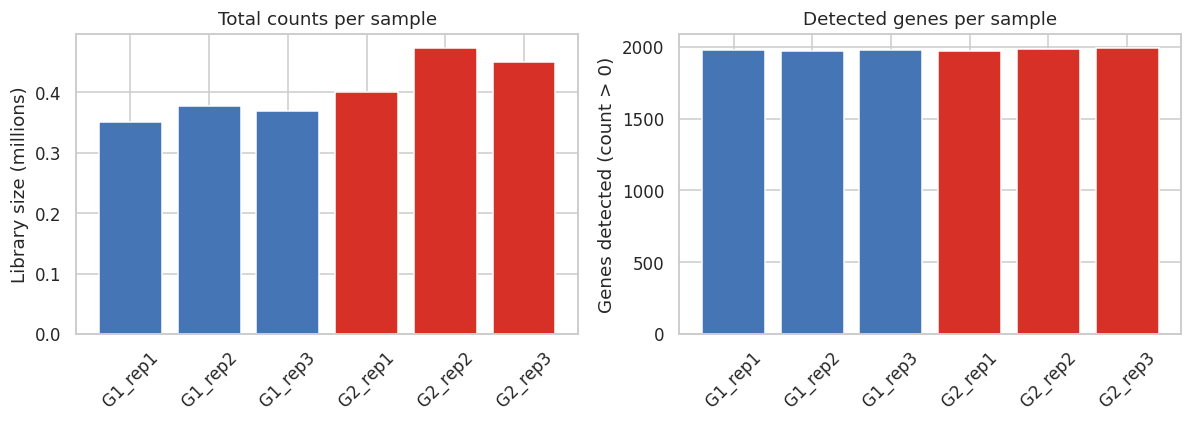

In [3]:
lib_size = counts.sum(axis=0)
detected = (counts > 0).sum(axis=0)
colors = [COND_COLORS[c] for c in meta["condition"]]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(meta.index, lib_size.loc[meta.index] / 1e6, color=colors)
axes[0].set(ylabel="Library size (millions)", title="Total counts per sample")
axes[1].bar(meta.index, detected.loc[meta.index], color=colors)
axes[1].set(ylabel="Genes detected (count > 0)", title="Detected genes per sample")
for ax in axes:
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

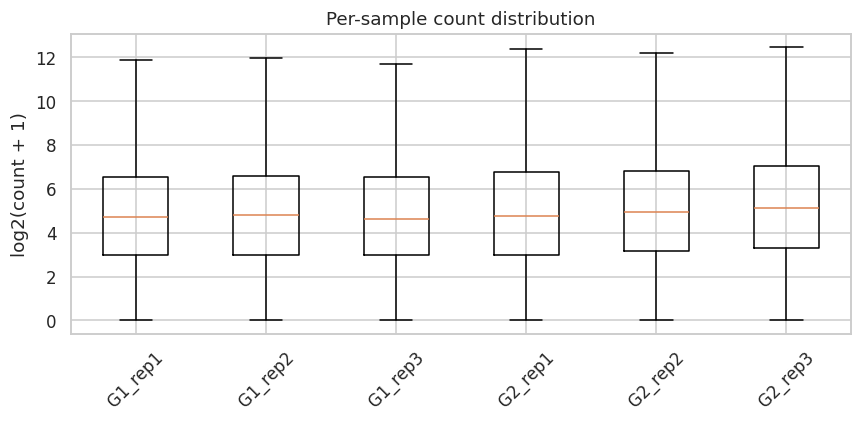

In [4]:
# Per-sample distribution of log-counts
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot([np.log2(counts[s] + 1) for s in meta.index],
           labels=meta.index, showfliers=False)
ax.set(ylabel="log2(count + 1)", title="Per-sample count distribution")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

## 4. Filter low-count genes

Genes with very few reads carry little information and inflate multiple-testing
correction. Here we keep genes with at least 10 reads in at least 3 samples
(the size of the smallest group).

In [5]:
min_group = meta["condition"].value_counts().min()
keep = (counts >= 10).sum(axis=1) >= min_group
counts_f = counts[keep]
print(f"Genes before filtering: {counts.shape[0]}")
print(f"Genes after  filtering: {counts_f.shape[0]}")

Genes before filtering: 2000
Genes after  filtering: 1455


## 5. Differential expression with PyDESeq2

[PyDESeq2](https://pydeseq2.readthedocs.io/) is a Python port of the DESeq2
method: it models counts with a negative binomial, estimates size factors and
gene-wise dispersions, and tests for differences between conditions. PyDESeq2
expects **samples as rows, genes as columns**, so we transpose the matrix.

In [6]:
dds = DeseqDataSet(
    counts=counts_f.T,            # samples x genes
    metadata=meta,
    design="~condition",
    ref_level=["condition", "G1"],  # G1 is the reference => results are G2 vs G1
    quiet=True,
)
dds.deseq2()

stat = DeseqStats(dds, contrast=["condition", "G2", "G1"], quiet=True)
stat.summary()
res = stat.results_df.sort_values("padj")
res.head(10)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene,,,,,,
BUB1,173.357919,3.259806,0.518034,6.292652,3.120878e-10,4.540878e-07
TOP2A,309.616240,3.470463,0.586230,5.919964,3.220117e-09,1.561757e-06
MCM4,494.423044,3.115876,0.522436,5.964129,2.459431e-09,1.561757e-06
IL1B,277.415905,3.464854,0.592051,5.852289,4.848535e-09,1.763655e-06
CCL2,185.346185,2.835322,0.494217,5.736993,9.637199e-09,2.804425e-06
CDC25A,213.355332,3.517068,0.623050,5.644919,1.652590e-08,3.981398e-06
BBC3,133.563729,-3.141546,0.559047,-5.619469,1.915449e-08,3.981398e-06
IRF7,415.575676,2.635675,0.481700,5.471610,4.459653e-08,8.110994e-06
IRF1,161.635465,2.783618,0.516884,5.385380,7.229179e-08,1.168717e-05


In [7]:
# Classify and summarise
res_clean = res.dropna(subset=["padj"]).copy()
sig = res_clean[(res_clean.padj < ALPHA) & (res_clean.log2FoldChange.abs() > LFC)]
n_up = int((sig.log2FoldChange > 0).sum())
n_down = int((sig.log2FoldChange < 0).sum())
print(f"Significant genes (padj < {ALPHA}, |log2FC| > {LFC}): {len(sig)}")
print(f"   up in G2:   {n_up}")
print(f"   down in G2: {n_down}")

res.to_csv(RESULTS / "de_results.csv")
print(f"Saved full results -> {RESULTS / 'de_results.csv'}")

Significant genes (padj < 0.05, |log2FC| > 1.0): 43
   up in G2:   34
   down in G2: 9
Saved full results -> ../results/de_results.csv


## 6. Normalization & sample structure

We use **log2 counts-per-million (logCPM)** for visualization — a simple,
robust normalization for between-sample comparison. PCA and a sample-correlation
heatmap should separate the two conditions if the biological signal dominates.

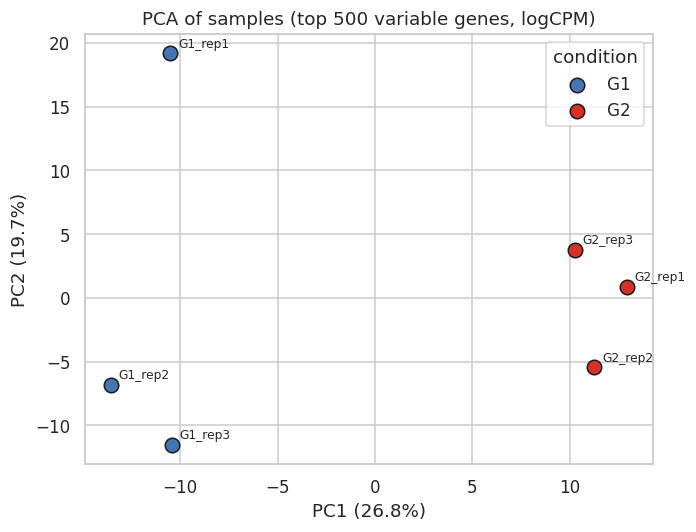

In [8]:
cpm = counts_f / counts_f.sum(axis=0) * 1e6
logcpm = np.log2(cpm + 1)

# PCA on the 500 most variable genes
top_var = logcpm.var(axis=1).sort_values(ascending=False).head(500).index
X = StandardScaler().fit_transform(logcpm.loc[top_var].T.values)  # samples x genes
pca = PCA(n_components=2).fit(X)
coords = pca.transform(X)
pv = (pca.explained_variance_ratio_ * 100).round(1)

fig, ax = plt.subplots(figsize=(6.5, 5))
for cond in meta["condition"].unique():
    idx = np.where(meta["condition"].values == cond)[0]
    ax.scatter(coords[idx, 0], coords[idx, 1], s=90,
               color=COND_COLORS[cond], label=cond, edgecolor="k")
for i, name in enumerate(meta.index):
    ax.annotate(name, (coords[i, 0], coords[i, 1]), fontsize=8,
                xytext=(5, 4), textcoords="offset points")
ax.set(xlabel=f"PC1 ({pv[0]}%)", ylabel=f"PC2 ({pv[1]}%)",
       title="PCA of samples (top 500 variable genes, logCPM)")
ax.legend(title="condition"); plt.tight_layout(); plt.show()

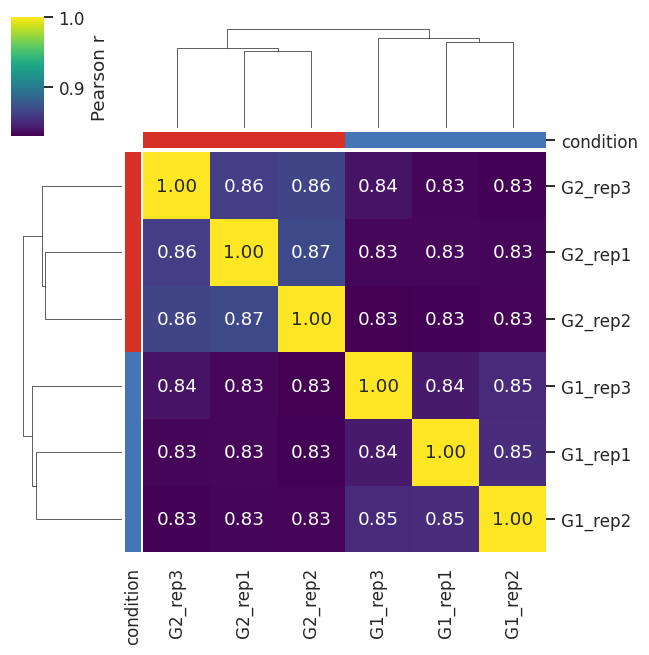

In [9]:
# Sample-to-sample correlation
corr = pd.DataFrame(np.corrcoef(logcpm.T.values),
                    index=logcpm.columns, columns=logcpm.columns)
col_colors = meta["condition"].map(COND_COLORS)
sns.clustermap(corr, cmap="viridis", annot=True, fmt=".2f", figsize=(6, 6),
               row_colors=col_colors, col_colors=col_colors,
               cbar_kws={"label": "Pearson r"})
plt.show()

## 7. MA plot and volcano plot

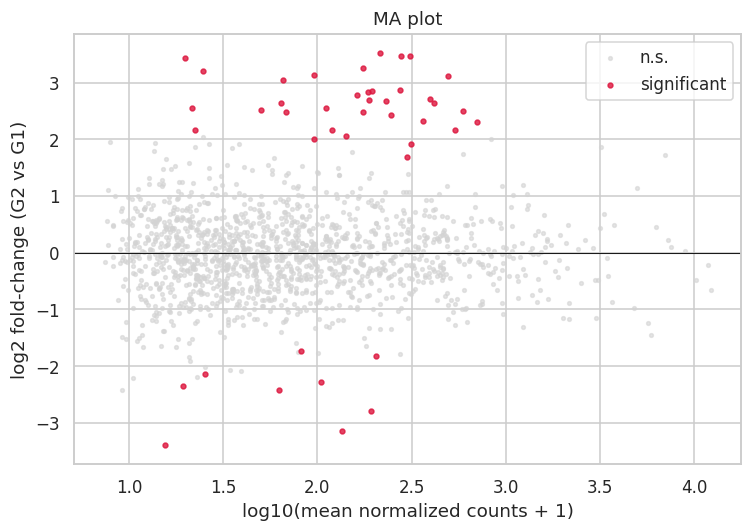

In [10]:
sig_mask = (res_clean.padj < ALPHA) & (res_clean.log2FoldChange.abs() > LFC)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(np.log10(res_clean.baseMean + 1)[~sig_mask],
           res_clean.log2FoldChange[~sig_mask],
           s=6, color="lightgrey", alpha=0.6, label="n.s.")
ax.scatter(np.log10(res_clean.baseMean + 1)[sig_mask],
           res_clean.log2FoldChange[sig_mask],
           s=10, color="crimson", alpha=0.8, label="significant")
ax.axhline(0, color="k", lw=0.7)
ax.set(xlabel="log10(mean normalized counts + 1)",
       ylabel="log2 fold-change (G2 vs G1)", title="MA plot")
ax.legend(); plt.tight_layout(); plt.show()

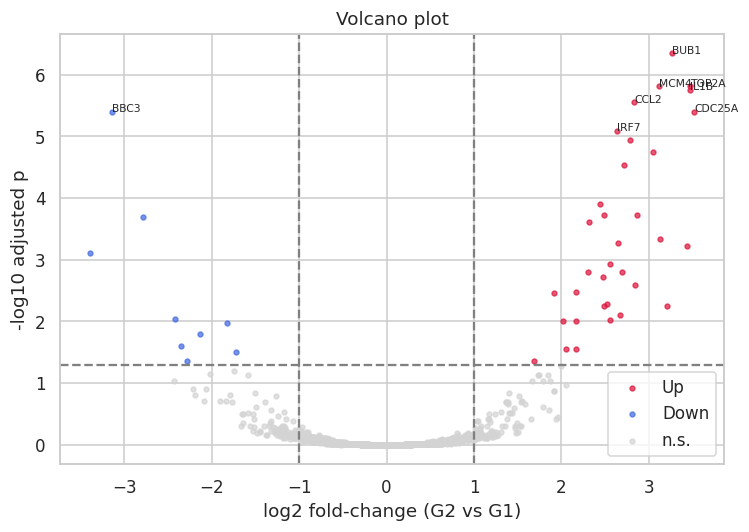

In [11]:
d = res_clean.copy()
d["cat"] = np.where((d.padj < ALPHA) & (d.log2FoldChange > LFC), "Up",
            np.where((d.padj < ALPHA) & (d.log2FoldChange < -LFC), "Down", "n.s."))
palette = {"Up": "crimson", "Down": "royalblue", "n.s.": "lightgrey"}

fig, ax = plt.subplots(figsize=(7, 5))
for cat, c in palette.items():
    sub = d[d.cat == cat]
    ax.scatter(sub.log2FoldChange, -np.log10(sub.padj.clip(lower=1e-300)),
               s=10, color=c, alpha=0.7, label=cat)
ax.axvline(-LFC, ls="--", color="grey"); ax.axvline(LFC, ls="--", color="grey")
ax.axhline(-np.log10(ALPHA), ls="--", color="grey")
for g in res.head(8).index:
    ax.annotate(g, (res.loc[g, "log2FoldChange"],
                    -np.log10(max(res.loc[g, "padj"], 1e-300))), fontsize=7)
ax.set(xlabel="log2 fold-change (G2 vs G1)", ylabel="-log10 adjusted p",
       title="Volcano plot")
ax.legend(); plt.tight_layout(); plt.show()

## 8. Heatmap of the top differentially expressed genes

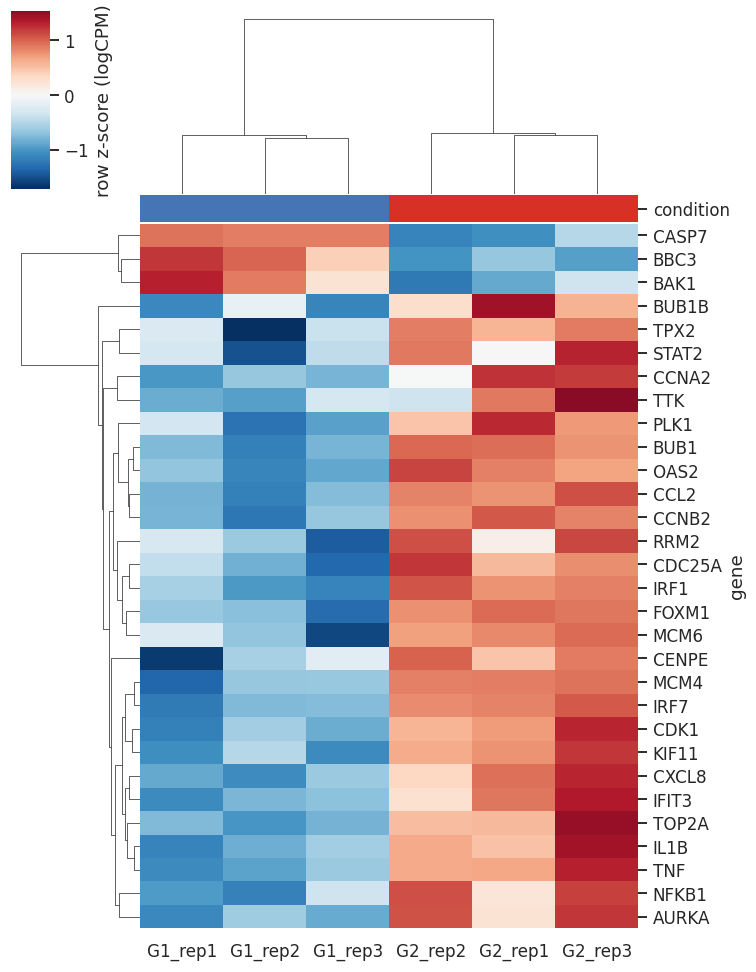

In [12]:
top_de = res.head(30).index
mat = logcpm.loc[top_de]
z = mat.sub(mat.mean(axis=1), axis=0).div(mat.std(axis=1) + 1e-9, axis=0)

sns.clustermap(z, cmap="RdBu_r", center=0, figsize=(7, 9),
               col_colors=meta["condition"].map(COND_COLORS),
               yticklabels=True, xticklabels=True,
               cbar_kws={"label": "row z-score (logCPM)"})
plt.show()

## 9. Functional enrichment (GO / KEGG)

We test whether the significant genes are enriched for **GO Biological Process**
terms and **KEGG pathways** using [gseapy](https://gseapy.readthedocs.io/)'s
Enrichr interface. (Background/synthetic `BG#####` ids are dropped — only real
gene symbols are submitted.)

> Enrichr is a web service, so this cell needs internet access. If unavailable
> it is skipped gracefully; rerun with a connection to get live results.

In [13]:
import gseapy as gp

real_sig = [g for g in sig.index if not g.startswith("BG")]
print(f"Submitting {len(real_sig)} genes to Enrichr:")
print(", ".join(real_sig))

try:
    enr = gp.enrichr(
        gene_list=real_sig,
        gene_sets=["GO_Biological_Process_2021", "KEGG_2021_Human"],
        organism="human", outdir=None,
    )
    top = enr.results.sort_values("Adjusted P-value").head(15)
    enr.results.to_csv(RESULTS / "enrichment.csv", index=False)
    print(f"\nSaved enrichment -> {RESULTS / 'enrichment.csv'}")
    display(top[["Gene_set", "Term", "Overlap", "Adjusted P-value", "Genes"]])
except Exception as e:
    print("\n[Enrichr unavailable — needs internet] "
          f"({type(e).__name__}). Rerun with a connection for live GO/KEGG terms.")

Submitting 38 genes to Enrichr:
BUB1, TOP2A, MCM4, IL1B, CCL2, CDC25A, BBC3, IRF7, IRF1, OAS2, CXCL8, FOXM1, PLK1, CDK1, BAK1, TNF, CENPE, IFIT3, KIF11, CASP7, NFKB1, RRM2, CCNA2, MCM6, TTK, AURKA, CCNB2, TPX2, BUB1B, STAT2, PTTG1, CASP9, MCM3, MAD2L1, ESPL1, STAT1, ISG15, CYCS



[Enrichr unavailable — needs internet] (HTTPError). Rerun with a connection for live GO/KEGG terms.


## 10. Summary

In [14]:
print("Analysis complete.\n")
print(f"  Genes analysed (after filtering): {counts_f.shape[0]}")
print(f"  Significant DE genes:             {len(sig)}  ({n_up} up, {n_down} down)")
print("\n  Output files in", RESULTS.resolve())
for f in sorted(RESULTS.glob("*")):
    print("   -", f.name)
print("\n  Top 5 differentially expressed genes:")
display(res.head(5)[["baseMean", "log2FoldChange", "padj"]])

Analysis complete.

  Genes analysed (after filtering): 1455
  Significant DE genes:             43  (34 up, 9 down)

  Output files in /home/claude/rnaseq-analysis-notebook/results
   - de_results.csv

  Top 5 differentially expressed genes:


,baseMean,log2FoldChange,padj
gene,,,
BUB1,173.357919,3.259806,4.540878e-07
TOP2A,309.616240,3.470463,1.561757e-06
MCM4,494.423044,3.115876,1.561757e-06
IL1B,277.415905,3.464854,1.763655e-06
CCL2,185.346185,2.835322,2.804425e-06
